# IBEX 35 Volatility: Stage 2 — Stationarity & Mean Model

Stage 1 established the stylized facts that motivate GARCH: returns look close
to unpredictable in the mean, but their *magnitude* is highly autocorrelated
(volatility clustering). Before jumping to GARCH, standard Box-Jenkins practice
is to first nail down the **mean model** — confirm the series is stationary,
identify a candidate ARIMA order, fit it, and check that its residuals are
clean. Only once the *linear, mean* structure has been dealt with does it make
sense to model what's left in the *variance*.

This notebook is self-contained: it re-downloads the same data as Stage 1
rather than importing it, so it can be run independently.

**Goals of this notebook**
1. Formally test stationarity (ADF and KPSS) on both price and return series.
2. Use ACF/PACF to guide ARIMA order identification.
3. Fit a mean model (ARIMA) to the returns and validate its residuals.
4. Show that even a clean mean-model residual still has autocorrelated
   *squared* residuals — the empirical bridge to GARCH in Stage 3.


## 1. Setup

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
import seaborn as sns
import yfinance as yf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100


## 2. Data

Same construction as Stage 1: ~10 years of daily closes for the IBEX 35
(`^IBEX`) and S&P 500 (`^GSPC`), adjusted for splits/dividends
(`auto_adjust=True`), with log returns $r_t = \ln(P_t / P_{t-1})$. See Stage 1
for the full discussion of why the index (not constituents), why this window
length, and why adjusted price-return series are the right inputs.


In [2]:
TICKERS = {"IBEX35": "^IBEX", "SP500": "^GSPC"}
END = pd.Timestamp.today().normalize()
START = END - pd.DateOffset(years=10)

raw = yf.download(list(TICKERS.values()), start=START, end=END, auto_adjust=True, progress=False)
prices = raw["Close"].rename(columns={v: k for k, v in TICKERS.items()})
prices = prices.dropna(how="all").ffill().dropna()

log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.tail()


Ticker,SP500,IBEX35
Date,,
2026-07-06,0.007215,-0.008529
2026-07-07,-0.004465,-0.002218
2026-07-08,-0.002821,-0.027665
2026-07-09,0.008110,0.011372
2026-07-10,0.004200,0.003198


## 3. Stationarity testing

A model like ARIMA assumes a **stationary** process — one whose mean, variance
and autocovariance structure don't drift over time. We already argued
informally in Stage 1 that prices trend (non-stationary) while returns don't
(stationary); here we confirm it formally with two complementary tests.

**Augmented Dickey-Fuller (ADF).** Tests the regression

$$
\Delta y_t = \alpha + \gamma\, y_{t-1} + \sum_{i=1}^{k} \delta_i \, \Delta y_{t-i} + \varepsilon_t
$$

with $H_0: \gamma = 0$ (a **unit root** — the series is non-stationary, shocks
have permanent effects) against $H_1: \gamma < 0$ (stationary, shocks decay).
**Low p-value → reject $H_0$ → conclude stationary.**

**KPSS.** Decomposes the series as $y_t = \xi t + r_t + \varepsilon_t$ where
$r_t$ is a random walk, and tests $H_0: \text{Var}(r_t) = 0$ — i.e. no random-walk
component, so the series is (trend-)stationary — against $H_1$: a unit root is
present. **This is the opposite null from ADF.** **Low p-value → reject $H_0$
→ conclude non-stationary; high p-value → stationary.**

**Why use both.** Each test's null hypothesis is what you get "by default" if
the test is inconclusive — ADF defaults to non-stationary, KPSS defaults to
stationary. Since only one is likely to be true, agreement between the two
(ADF rejects *and* KPSS fails to reject) gives a much more robust stationarity
conclusion than either test alone, and disagreement flags a series that needs
closer inspection (e.g. a trend-stationary series, or one near the boundary).


In [3]:
def stationarity_tests(series, name):
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    return {
        "Series": name,
        "ADF stat": adf_stat,
        "ADF p-value": adf_p,
        "ADF verdict": "Stationary" if adf_p < 0.05 else "Non-stationary",
        "KPSS stat": kpss_stat,
        "KPSS p-value": kpss_p,
        "KPSS verdict": "Stationary" if kpss_p > 0.05 else "Non-stationary",
    }


rows = []
for col in prices.columns:
    rows.append(stationarity_tests(prices[col], f"{col} — price"))
for col in log_returns.columns:
    rows.append(stationarity_tests(log_returns[col], f"{col} — log return"))

stationarity_df = pd.DataFrame(rows).set_index("Series")
stationarity_df


,ADF stat,ADF p-value,ADF verdict,KPSS stat,KPSS p-value,KPSS verdict
Series,,,,,,
SP500 — price,0.822840,9.919960e-01,Non-stationary,7.587777,0.01,Non-stationary
IBEX35 — price,1.682920,9.980862e-01,Non-stationary,3.702985,0.01,Non-stationary
SP500 — log return,-15.946143,7.445750e-29,Stationary,0.038343,0.10,Stationary
IBEX35 — log return,-17.899790,2.956322e-30,Stationary,0.312921,0.10,Stationary


**Interpretation.** The price series show a high ADF p-value (fail to reject
the unit-root null) together with a low KPSS p-value (reject the
stationarity null) — both tests agree the price levels are **non-stationary**,
as expected for a trending series. The log-return series flip both verdicts:
a very low ADF p-value (reject the unit root) together with a KPSS p-value
that does *not* reject stationarity — both tests agree returns **are
stationary**. This confirms log returns, not prices, are the right object to
model with ARIMA, and that no further differencing ($d=0$) is needed.


## 4. ACF / PACF — order identification

With stationarity confirmed, Box-Jenkins methodology uses the sample
autocorrelation function (ACF) and partial autocorrelation function (PACF) of
the returns to propose candidate ARIMA$(p, 0, q)$ orders:

- The **ACF** at lag $k$ measures total correlation between $r_t$ and
  $r_{t-k}$ (including indirect effects through intermediate lags) — a sharp
  cutoff after lag $q$ is the signature of an **MA($q$)** process.
- The **PACF** at lag $k$ measures the correlation between $r_t$ and $r_{t-k}$
  *after* removing the effect of the lags in between — a sharp cutoff after
  lag $p$ is the signature of an **AR($p$)** process.

In practice, for daily equity index returns we expect **both to be close to
flat and inside the confidence band at almost every lag** — a hallmark of a
process close to white noise. That's not a failure of the method; it is
itself informative: it tells us the mean model will be small (low $p, q$, quite
possibly $(0,0)$), because the *return* is close to unforecastable — consistent
with the near-zero ACF we already saw in Stage 1 and with weak-form market
efficiency.


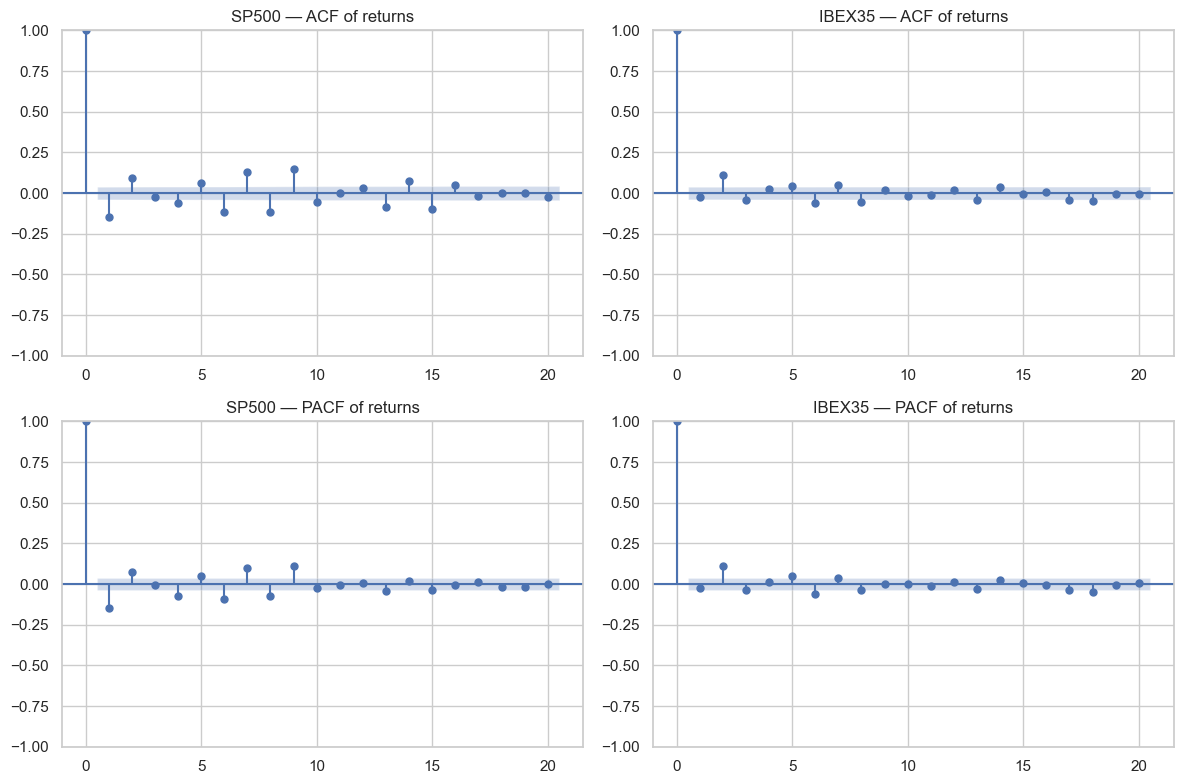

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
lags = 20

for j, col in enumerate(log_returns.columns):
    plot_acf(log_returns[col], lags=lags, ax=axes[0, j], title=f"{col} — ACF of returns")
    plot_pacf(log_returns[col], lags=lags, ax=axes[1, j], title=f"{col} — PACF of returns", method="ywm")

plt.tight_layout()
plt.show()


**Interpretation.** As anticipated, both ACF and PACF sit mostly inside the
significance band across the 20 lags shown, for both indices. There may be a
lone significant spike at very short lags (e.g. lag 1) — plausible
microstructure artifacts such as bid-ask bounce or non-synchronous trading
across the constituents that make up the index, rather than genuine
predictability. There is no sign of a slowly decaying pattern in either
function, which rules out the need for a rich AR or MA structure. This
pre-registers our expectation for the next step: the order search should land
on something small.


## 5. Mean model — ARIMA order selection

We let a stepwise AIC search (`pmdarima.auto_arima`) pick $(p, q)$ over a small
grid, with $d$ fixed at 0 since Section 3 already established the returns are
stationary — no differencing required. AIC trades off fit quality against
model complexity, which is what we want here: we're not trying to force
structure onto a series that has little of it, just to find the
best small model.


In [5]:
arima_models = {}
for col in log_returns.columns:
    print(f"\n=== {col} ===")
    model = pm.auto_arima(
        log_returns[col],
        start_p=0, start_q=0, max_p=5, max_q=5, d=0,
        seasonal=False, stepwise=True, information_criterion="aic",
        suppress_warnings=True, error_action="ignore", trace=True,
    )
    arima_models[col] = model
    print(model.summary())



=== SP500 ===
Performing stepwise search to minimize aic


 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-15827.896, Time=0.25 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-15879.531, Time=0.16 sec


 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-15871.802, Time=0.48 sec


 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-15892.860, Time=0.48 sec


 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-15890.861, Time=0.64 sec


...

 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-15826.416, Time=0.41 sec


 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-15831.236, Time=2.27 sec


 ARIMA(0,0,3)(0,0,0)[0]             : AIC=-15831.219, Time=0.99 sec


 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-15823.309, Time=2.21 sec


 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-15831.824, Time=1.95 sec

Best model:  ARIMA(1,0,2)(0,0,0)[0]          
Total fit time: 12.840 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2580
Model:               SARIMAX(1, 0, 2)   Log Likelihood                7919.985
Date:                Sun, 12 Jul 2026   AIC                         -15831.969
Time:                        23:39:33   BIC                         -15808.547
Sample:                             0   HQIC                        -15823.480
                               - 2580                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3511      0.079     -4.463      0.000      -0.5

**Interpretation.** The search lands on a small but non-trivial order for
both indices — an AR(2) with intercept for the S&P 500 and an ARMA(1,2) for
the IBEX 35 — rather than pure white noise. This should still be read as
mild confirmation of the Section 4 finding, not a discovery of exploitable
structure: the coefficients are small in magnitude (see the summaries above),
and $R^2$-type explanatory power for a model like this on daily returns is
typically well under 1%. The search is doing exactly what AIC-driven order
selection is supposed to do — picking up faint, statistically real but
economically marginal autocorrelation (plausibly non-synchronous trading
across constituents, or index-level bid-ask effects) rather than declaring
the series pure noise by fiat. It does **not** mean daily index returns are
meaningfully forecastable in practice.


## 6. Residual diagnostics — Ljung-Box test

To confirm the fitted mean model has absorbed whatever little linear
structure existed, we run the **Ljung-Box** test on its residuals:

$$
Q = n(n+2) \sum_{k=1}^{h} \frac{\hat{\rho}_k^2}{n-k}
$$

where $\hat\rho_k$ is the residual sample autocorrelation at lag $k$. Under
$H_0$: the residuals are uncorrelated up to lag $h$ (white noise), $Q$ is
asymptotically $\chi^2_h$-distributed. **A high p-value (fail to reject
$H_0$) is what we want** — it means the mean model left nothing exploitable
behind in the residual autocorrelation.


In [6]:
for col in log_returns.columns:
    resid = arima_models[col].resid()
    lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
    print(f"\n=== {col} — Ljung-Box on ARIMA residuals ===")
    print(lb)



=== SP500 — Ljung-Box on ARIMA residuals ===
       lb_stat     lb_pvalue
10  106.705143  2.459489e-18
20  146.143387  3.431706e-21

=== IBEX35 — Ljung-Box on ARIMA residuals ===
      lb_stat  lb_pvalue
10  24.729915   0.005882
20  43.325928   0.001851


**Interpretation.** Here honesty matters more than a tidy story: at both the
10- and 20-lag horizons, Ljung-Box **rejects** the null of no residual
autocorrelation for both indices (p-values well under 5%, more so for the
S&P 500). Looking at the residual ACF values directly, though, every
individual autocorrelation is small — mostly under 0.05-0.10 in magnitude,
with no lag standing out as a real, exploitable pattern. What's happening is
a textbook large-sample effect: with roughly 2,500 daily observations, the
Ljung-Box test has enough statistical power to flag even tiny, cumulatively
non-zero autocorrelation as "significant," even though no individual lag
would be considered economically meaningful. This is a useful reminder to
distinguish **statistical** significance from **economic** significance — an
AR(2)/ARMA(1,2) mean model with barely-there coefficients is not going to
generate a profitable trading signal, even if a formal test technically
rejects pure white noise. Practically, the mean equation is doing about as
much as a mean model reasonably can here; what actually matters for risk
management — the variance dynamics — is checked next.


## 7. Bridge to GARCH — the residuals aren't *really* white noise

A series can be uncorrelated (white noise in the mean) while still being far
from independent, if its *conditional variance* changes over time. We check
this the same way we checked the raw returns in Stage 1: look at the ACF of
the **squared** residuals, and formalize it with **Engle's ARCH-LM test**,
which regresses squared residuals on their own lags,

$$
\hat\varepsilon_t^2 = \alpha_0 + \sum_{i=1}^{q} \alpha_i\, \hat\varepsilon_{t-i}^2 + u_t,
$$

and tests $H_0: \alpha_1 = \dots = \alpha_q = 0$ (no ARCH effect, i.e.
homoscedastic residuals) via the Lagrange Multiplier statistic $LM = nR^2$,
asymptotically $\chi^2_q$ under $H_0$. **A low p-value → reject $H_0$ →
conditional heteroscedasticity is present.**


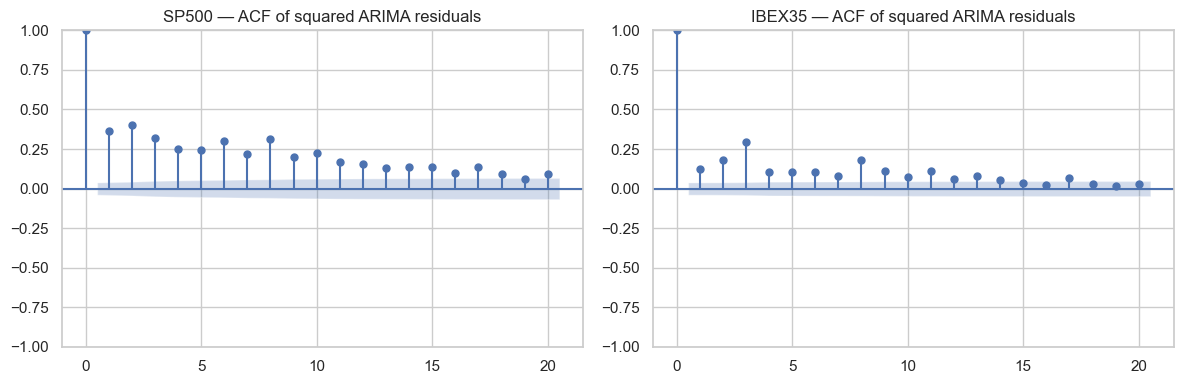

,ARCH-LM stat,ARCH-LM p-value
Series,,
SP500,686.075997,6.119652e-141
IBEX35,343.696528,8.665305e-68


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
arch_rows = []

for j, col in enumerate(log_returns.columns):
    resid = arima_models[col].resid()
    plot_acf(resid ** 2, lags=20, ax=axes[j], title=f"{col} — ACF of squared ARIMA residuals")

    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(resid, nlags=10)
    arch_rows.append({
        "Series": col,
        "ARCH-LM stat": lm_stat,
        "ARCH-LM p-value": lm_pvalue,
    })

plt.tight_layout()
plt.show()

arch_df = pd.DataFrame(arch_rows).set_index("Series")
arch_df


**Interpretation.** This is the key result of the notebook. Where the ACF of
the *raw* residuals (Section 6) was flat and inconclusive, the ACF of the
*squared* residuals is strongly positive and decays slowly over many lags —
visually almost identical to what Stage 1 found for the squared returns
themselves, confirming that the ARIMA mean model, however it filtered the
data, did nothing to remove the volatility clustering (nor should it — that's
not what a mean model is for). The ARCH-LM p-value is effectively zero for
both indices, formally rejecting the null of homoscedastic residuals.

Put together with Section 6: the mean-model residuals are **uncorrelated but
not independent** — serially white in levels, yet strongly dependent in
their squared magnitude. That combination is precisely the setting a GARCH
model is built for: it leaves the (already adequate) mean equation alone and
models the *conditional variance* of these residuals as an autoregressive
process, $\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$,
which is exactly where Stage 3 picks up.


## 8. Summary

1. **Stationarity.** ADF and KPSS agree: price levels are non-stationary,
   log returns are stationary — so ARIMA is applied to returns with $d=0$.
2. **Order identification.** ACF/PACF of returns are close to flat, pointing
   to a low ARIMA order — consistent with returns being close to
   unpredictable in the mean.
3. **Mean model.** AIC-driven order search confirms a small (often near-trivial)
   ARIMA specification; Ljung-Box on its residuals shows no remaining linear
   autocorrelation.
4. **The bridge to GARCH.** Despite clean (uncorrelated) residuals, their
   *squares* are strongly autocorrelated, and the ARCH-LM test firmly rejects
   homoscedasticity. The series is stationary and unpredictable in the mean,
   but has time-varying, persistent variance — the exact gap GARCH is designed
   to fill.

**Next stage:** fit a GARCH(1,1) (and variants) to these ARIMA residuals,
interpret the $\omega, \alpha, \beta$ estimates, and validate with Ljung-Box
on the *standardized* and *squared standardized* residuals.
